# Predictive Modeling Using Machine Learning

## Objective
Build machine learning models to predict outcomes using restaurant tipping data.

## Algorithms Used
- Linear Regression
- Decision Tree
- Random Forest

## Evaluation Methods
- RMSE
- R² Score
- Accuracy
- Confusion Matrix
- ROC Curve

# Load libraries

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Regression models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Classification models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    accuracy_score,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)

# Load dataset

In [7]:
df = pd.read_csv(r"C:\Users\moham\OneDrive\Desktop\hackathon\predictive_modeling_project\data/cleaned_tips.csv")

df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


# Dataset information

In [8]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 234 entries, 0 to 233
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  234 non-null    float64
 1   tip         234 non-null    float64
 2   sex         234 non-null    object 
 3   smoker      234 non-null    object 
 4   day         234 non-null    object 
 5   time        234 non-null    object 
 6   size        234 non-null    int64  
dtypes: float64(2), int64(1), object(4)
memory usage: 12.9+ KB


,total_bill,tip,size
count,234.000000,234.000000,234.000000
mean,18.823462,2.905342,2.525641
std,7.444686,1.226852,0.913293
min,3.070000,1.000000,1.000000
25%,13.272500,2.000000,2.000000
50%,17.465000,2.750000,2.000000
75%,23.152500,3.500000,3.000000
max,40.170000,7.580000,6.000000


# Data Exploration

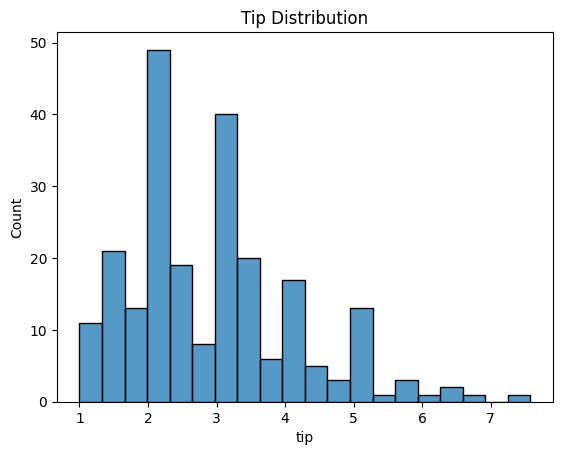

In [10]:
#Tip distribution
sns.histplot(df['tip'], bins=20)

plt.title("Tip Distribution")

plt.show()

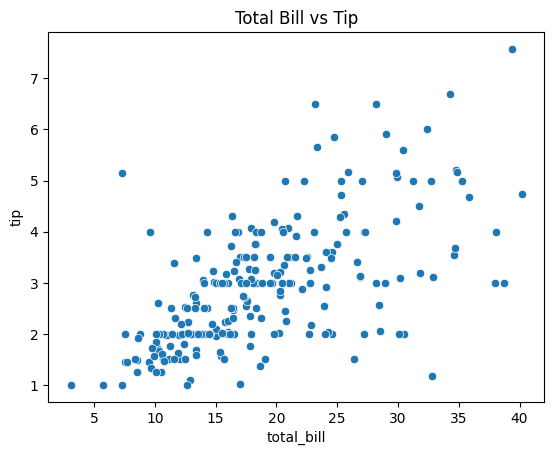

In [11]:
#Bill vs Tip
sns.scatterplot(x='total_bill', y='tip', data=df)

plt.title("Total Bill vs Tip")

plt.show()

# Data preprocessing

In [12]:
le = LabelEncoder()

df['sex'] = le.fit_transform(df['sex'])
df['smoker'] = le.fit_transform(df['smoker'])
df['day'] = le.fit_transform(df['day'])
df['time'] = le.fit_transform(df['time'])

# Regression problem

In [13]:
X = df.drop('tip', axis=1)

y = df['tip']

In [14]:
#Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Train regression models

In [15]:
lr = LinearRegression()

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

# Decision tree

In [16]:
dt = DecisionTreeRegressor()

dt.fit(X_train, y_train)

pred_dt = dt.predict(X_test)

# Random forest

In [17]:
rf = RandomForestRegressor()

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

# Evaluate models

In [18]:
def evaluate(y_test, pred):

    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)

    return rmse, r2

In [19]:
models = {
    "Linear Regression": pred_lr,
    "Decision Tree": pred_dt,
    "Random Forest": pred_rf
}

for name, pred in models.items():

    rmse, r2 = evaluate(y_test, pred)

    print(name)
    print("RMSE:", rmse)
    print("R2:", r2)
    print("----------")

Linear Regression
RMSE: 1.0930451368519498
R2: 0.3592653380802666
----------
Decision Tree
RMSE: 1.3918348520277644
R2: -0.03890883700920922
----------
Random Forest
RMSE: 1.1208669592888947
R2: 0.3262323413978765
----------


# Convert to classification problem

In [20]:
df['high_tip'] = (df['tip'] > df['tip'].median()).astype(int)

In [21]:
#define variables
X_cls = df.drop(['tip','high_tip'], axis=1)

y_cls = df['high_tip']

In [22]:
#split data
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cls, y_cls,
    test_size=0.2,
    random_state=42
)

# Train classification models

In [23]:
# decision tree classifier
dtc = DecisionTreeClassifier()

dtc.fit(X_train_c, y_train_c)

pred_dtc = dtc.predict(X_test_c)

In [24]:
#Random forest classifier
rfc = RandomForestClassifier()

rfc.fit(X_train_c, y_train_c)

pred_rfc = rfc.predict(X_test_c)

# Accuracy evaluation

In [25]:
print("Decision Tree Accuracy:", accuracy_score(y_test_c, pred_dtc))

print("Random Forest Accuracy:", accuracy_score(y_test_c, pred_rfc))

Decision Tree Accuracy: 0.6382978723404256
Random Forest Accuracy: 0.6382978723404256


# Confusion matrix

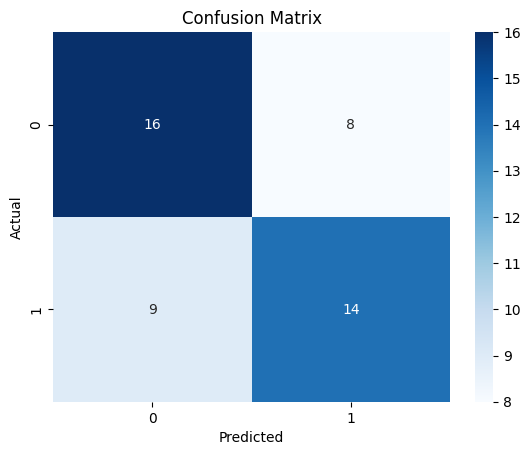

In [26]:
cm = confusion_matrix(y_test_c, pred_rfc)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

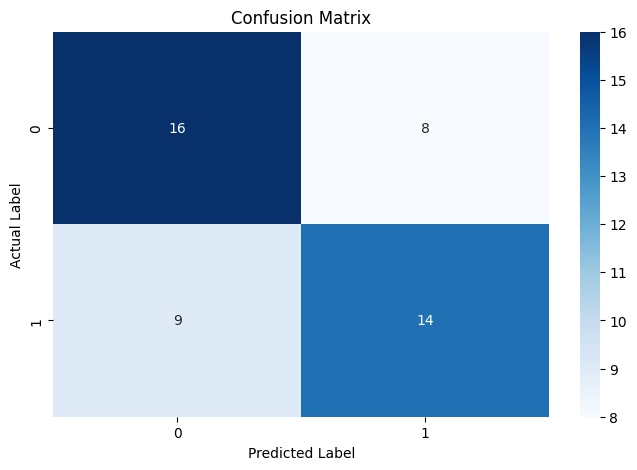

In [36]:
plt.figure(figsize=(8,5))

cm = confusion_matrix(y_test_c, pred_rfc)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")

plt.savefig(r"C:\Users\moham\OneDrive\Desktop\hackathon\predictive_modeling_project\outputs\confusion_matrix.png")

plt.show()

# ROC curve

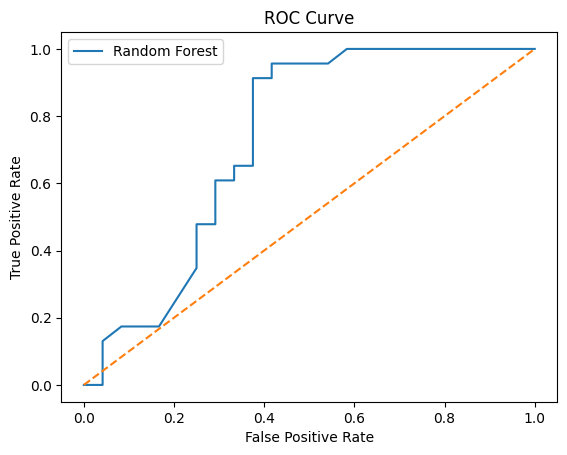

In [27]:
prob = rfc.predict_proba(X_test_c)[:,1]

fpr, tpr, threshold = roc_curve(y_test_c, prob)

plt.plot(fpr, tpr, label="Random Forest")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

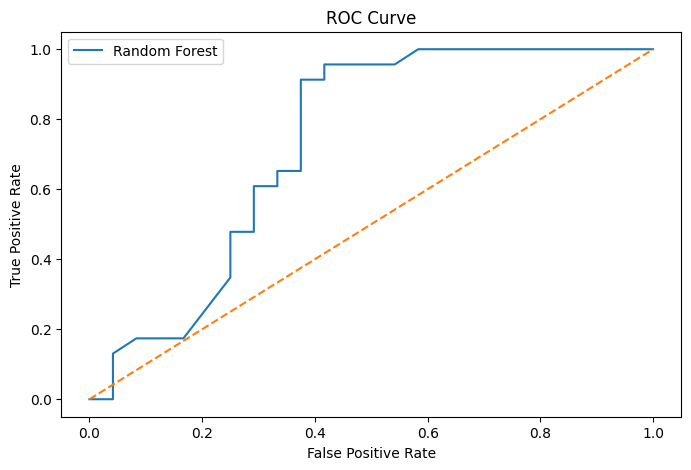

In [37]:
plt.figure(figsize=(8,5))

prob = rfc.predict_proba(X_test_c)[:,1]

fpr, tpr, threshold = roc_curve(y_test_c, prob)

plt.plot(fpr, tpr, label="Random Forest")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.savefig(r"C:\Users\moham\OneDrive\Desktop\hackathon\predictive_modeling_project\outputs\roc_curve.png")

plt.show()

# Feature importance

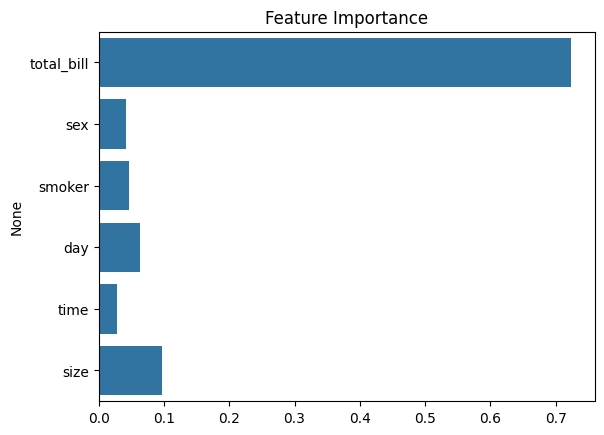

In [28]:
importance = rfc.feature_importances_

features = X_cls.columns

sns.barplot(x=importance, y=features)

plt.title("Feature Importance")

plt.show()

## Conclusion

This project implemented predictive modeling using machine learning.

Models Used
- Linear Regression
- Decision Tree
- Random Forest

Regression models predicted the tip amount, while classification models predicted whether a tip was high or low.

Random Forest performed best in both regression and classification tasks.

This project demonstrates supervised learning techniques and model evaluation using multiple metrics including accuracy, confusion matrix, and ROC curve.